In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize, LinearConstraint, milp
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

from genetic_algorithm_pfm.tetra_pfm import TetraSolver

# Initialize TetraSolver
solver = TetraSolver()

%matplotlib inline
plt.rcParams['figure.dpi'] = 400
plt.rcParams.update({'font.size': 14})

In [2]:
# x1 : The length of the tunnel 
# x2 : number of lanes

# define the objective functions
def objective_costs(x):
    x1, x2 = x
    return C6 * B1 * x1 + C2 * C6 * x2

def objective_traffic_flow(x):
    x1, x2 = x
    return (B2 * B3 * x2) / x1

In [3]:
# define bounds

bounds = [(815, 1035),(2, 8)]
b1, b2 = bounds[0]
b3, b4 = bounds[1]

In [4]:
# define constants

B1 = 211680         # [kg/m]      mass per length
C2 = 6234971        # [kg/n]      mass per lane
C6 = 0.125          # [€/ kg]     cost per kg concrete
B2 = 100 * 10**3    # [m/h]       speed
B3 = 50             # [veh]       Average number of vehicles in the tunnel

In [5]:
# initiate optimization
result1 = minimize(objective_costs, x0=np.array([1, 1]), bounds=bounds)
result2 = minimize(objective_traffic_flow, x0=np.array([1, 1]), bounds=bounds)

optimal_result_O1 = result1.fun
optimal_result_O2 = result2.fun

# print results
print('Results Minimize')
print(f'Objective 1 is minimal for x1 = {result1.x[0]} and x2 = {result1.x[1]}. The costs are then {result1.fun}.')
print(f'Objective 2 is minimal for x1 = {result2.x[0]} and x2 = {result2.x[1]}. The traffic flow is then {result2.fun}.')
print()


Results Minimize
Objective 1 is minimal for x1 = 815.0 and x2 = 2.0. The costs are then 23123642.75.
Objective 2 is minimal for x1 = 1035.0 and x2 = 2.0. The traffic flow is then 9661.835748792271.



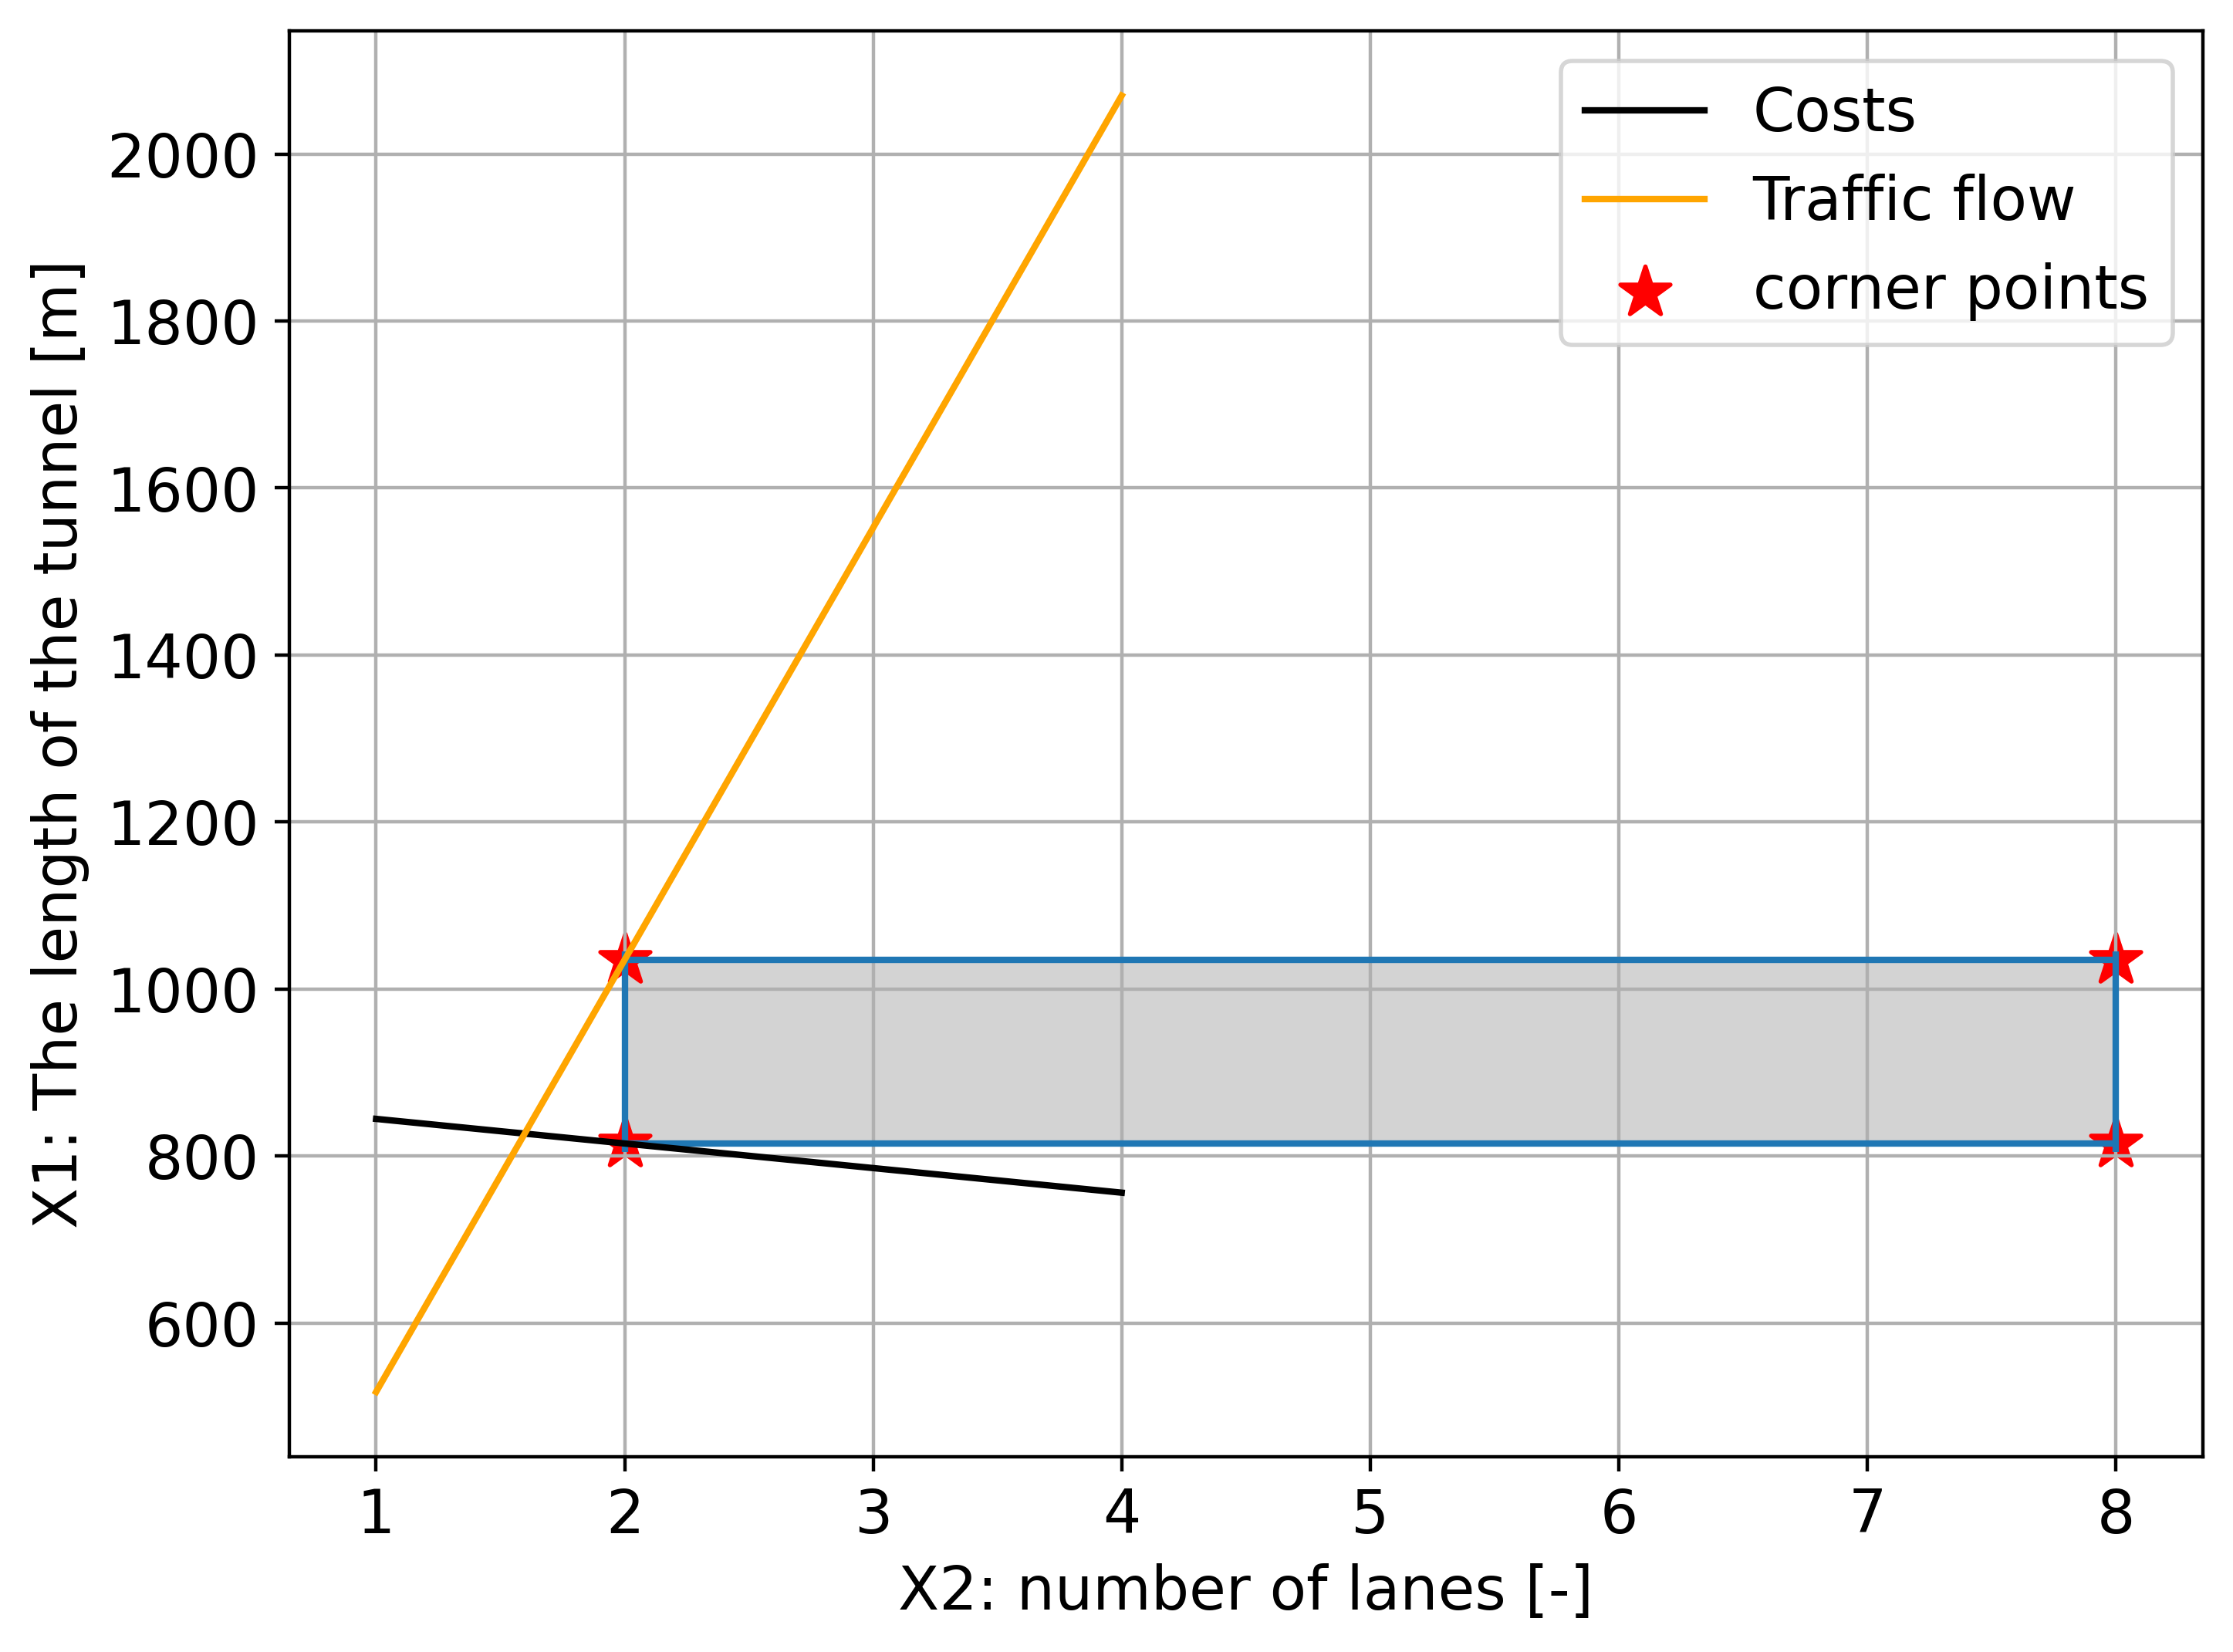

In [13]:
# plot graphical solution
fig, ax = plt.subplots(figsize=(8, 6))

# Draw constraint lines
ax.vlines(b3, b1-10, b2+10)
ax.vlines(b4, b1-10, b2+10)
ax.hlines(b1, b3, b4)
ax.hlines(b2, b3, b4)

# Draw the feasible region
feasible_set = Polygon(np.array([[b3, b1],
                                 [b4, b1],
                                 [b4, b2],
                                 [b3, b2]]),
                       color="lightgrey")
ax.add_patch(feasible_set)

ax.set_xlabel('X2: number of lanes [-]')
ax.set_ylabel('X1: The length of the tunnel [m]')

# Draw the objective function
x2 = np.linspace(1, 4)
ax.plot(x2, (optimal_result_O1 - C2*C6*x2)/(C6*B1), color="black", label='Costs')

ax.plot(x2,(B2*B3*x2)/(optimal_result_O2 ), color="orange", label='Traffic flow')

ax.scatter([b3,b3,b4,b4], [b1,b2,b1,b2], marker='*', color='red', label='corner points', s=150)

ax.legend()
ax.grid()
plt.savefig('2x2.png');

In [7]:
min1, max1 = optimal_result_O1, objective_costs([b2, b4])
min2, max2 = optimal_result_O2, objective_traffic_flow([b2, b4])

# define the preference functions
def preference_P1(variables):
    x1 = variables[:, 0]
    x2 = variables[:, 1]

    costs = objective_costs([x1, x2])
    return 100 * max1 / (max1 - min1) + 100 * costs / (min1 - max1)

def preference_P2(variables):
    x1 = variables[:, 0]
    x2 = variables[:, 1]

    traffic_flow = objective_traffic_flow([x1, x2])
    return 100 * max2 / (max2 - min2) + 100 * traffic_flow / (min2 - max2)

# the alternatives (corner points)
alternatives = np.array([[b1, b3],
                         [b1, b4],
                         [b2, b3],
                         [b2, b4]])

P1 = preference_P1(alternatives)
P2 = preference_P2(alternatives)

w = [0.2, 0.8] # weights
p = [P1, P2]

ret = solver.request(w, p)

# add results to DataFrame and print it
results = np.zeros((4, 3))
results[:, 0] = alternatives[:, 0]
results[:, 1] = alternatives[:, 1]
results[:, 2] = np.multiply(-1, ret)

df = pd.DataFrame(np.round_(results, 2), columns=['x1', 'x2', 'Aggregated preference'])
print(df)

       x1   x2  Aggregated preference
0   815.0  2.0                 100.00
1   815.0  8.0                   0.00
2  1035.0  2.0                  90.56
3  1035.0  8.0                   9.15


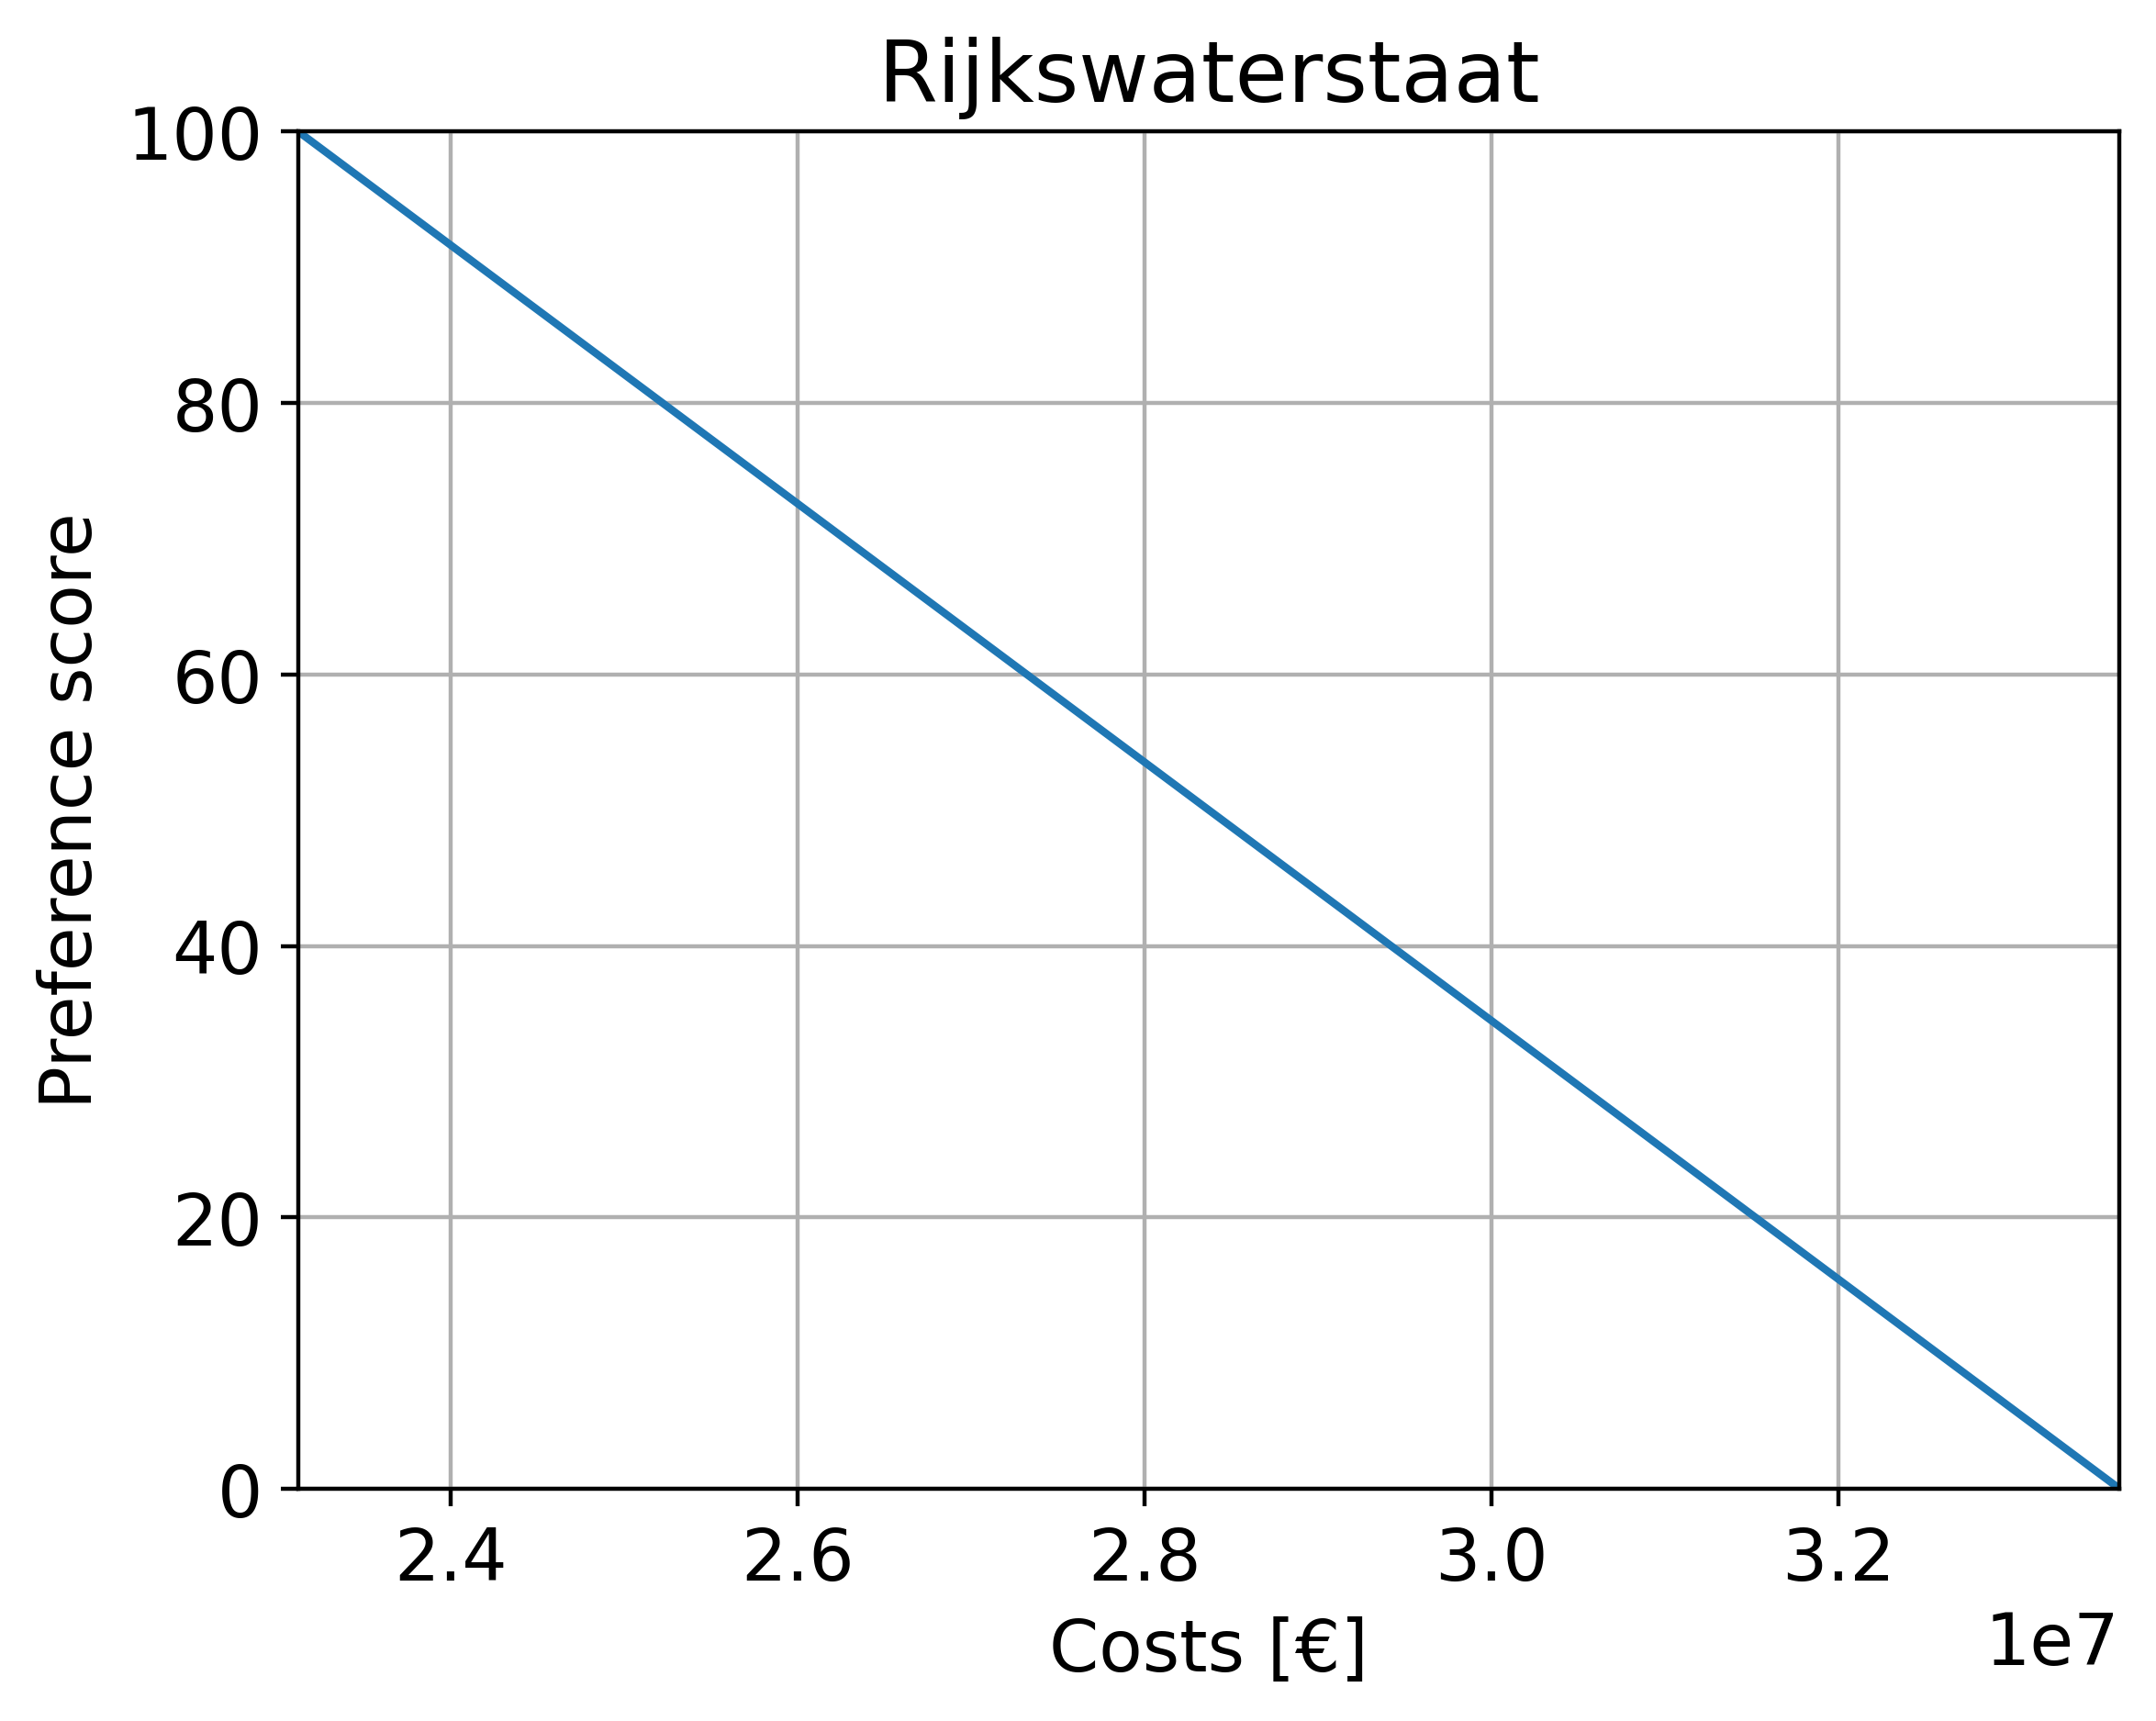

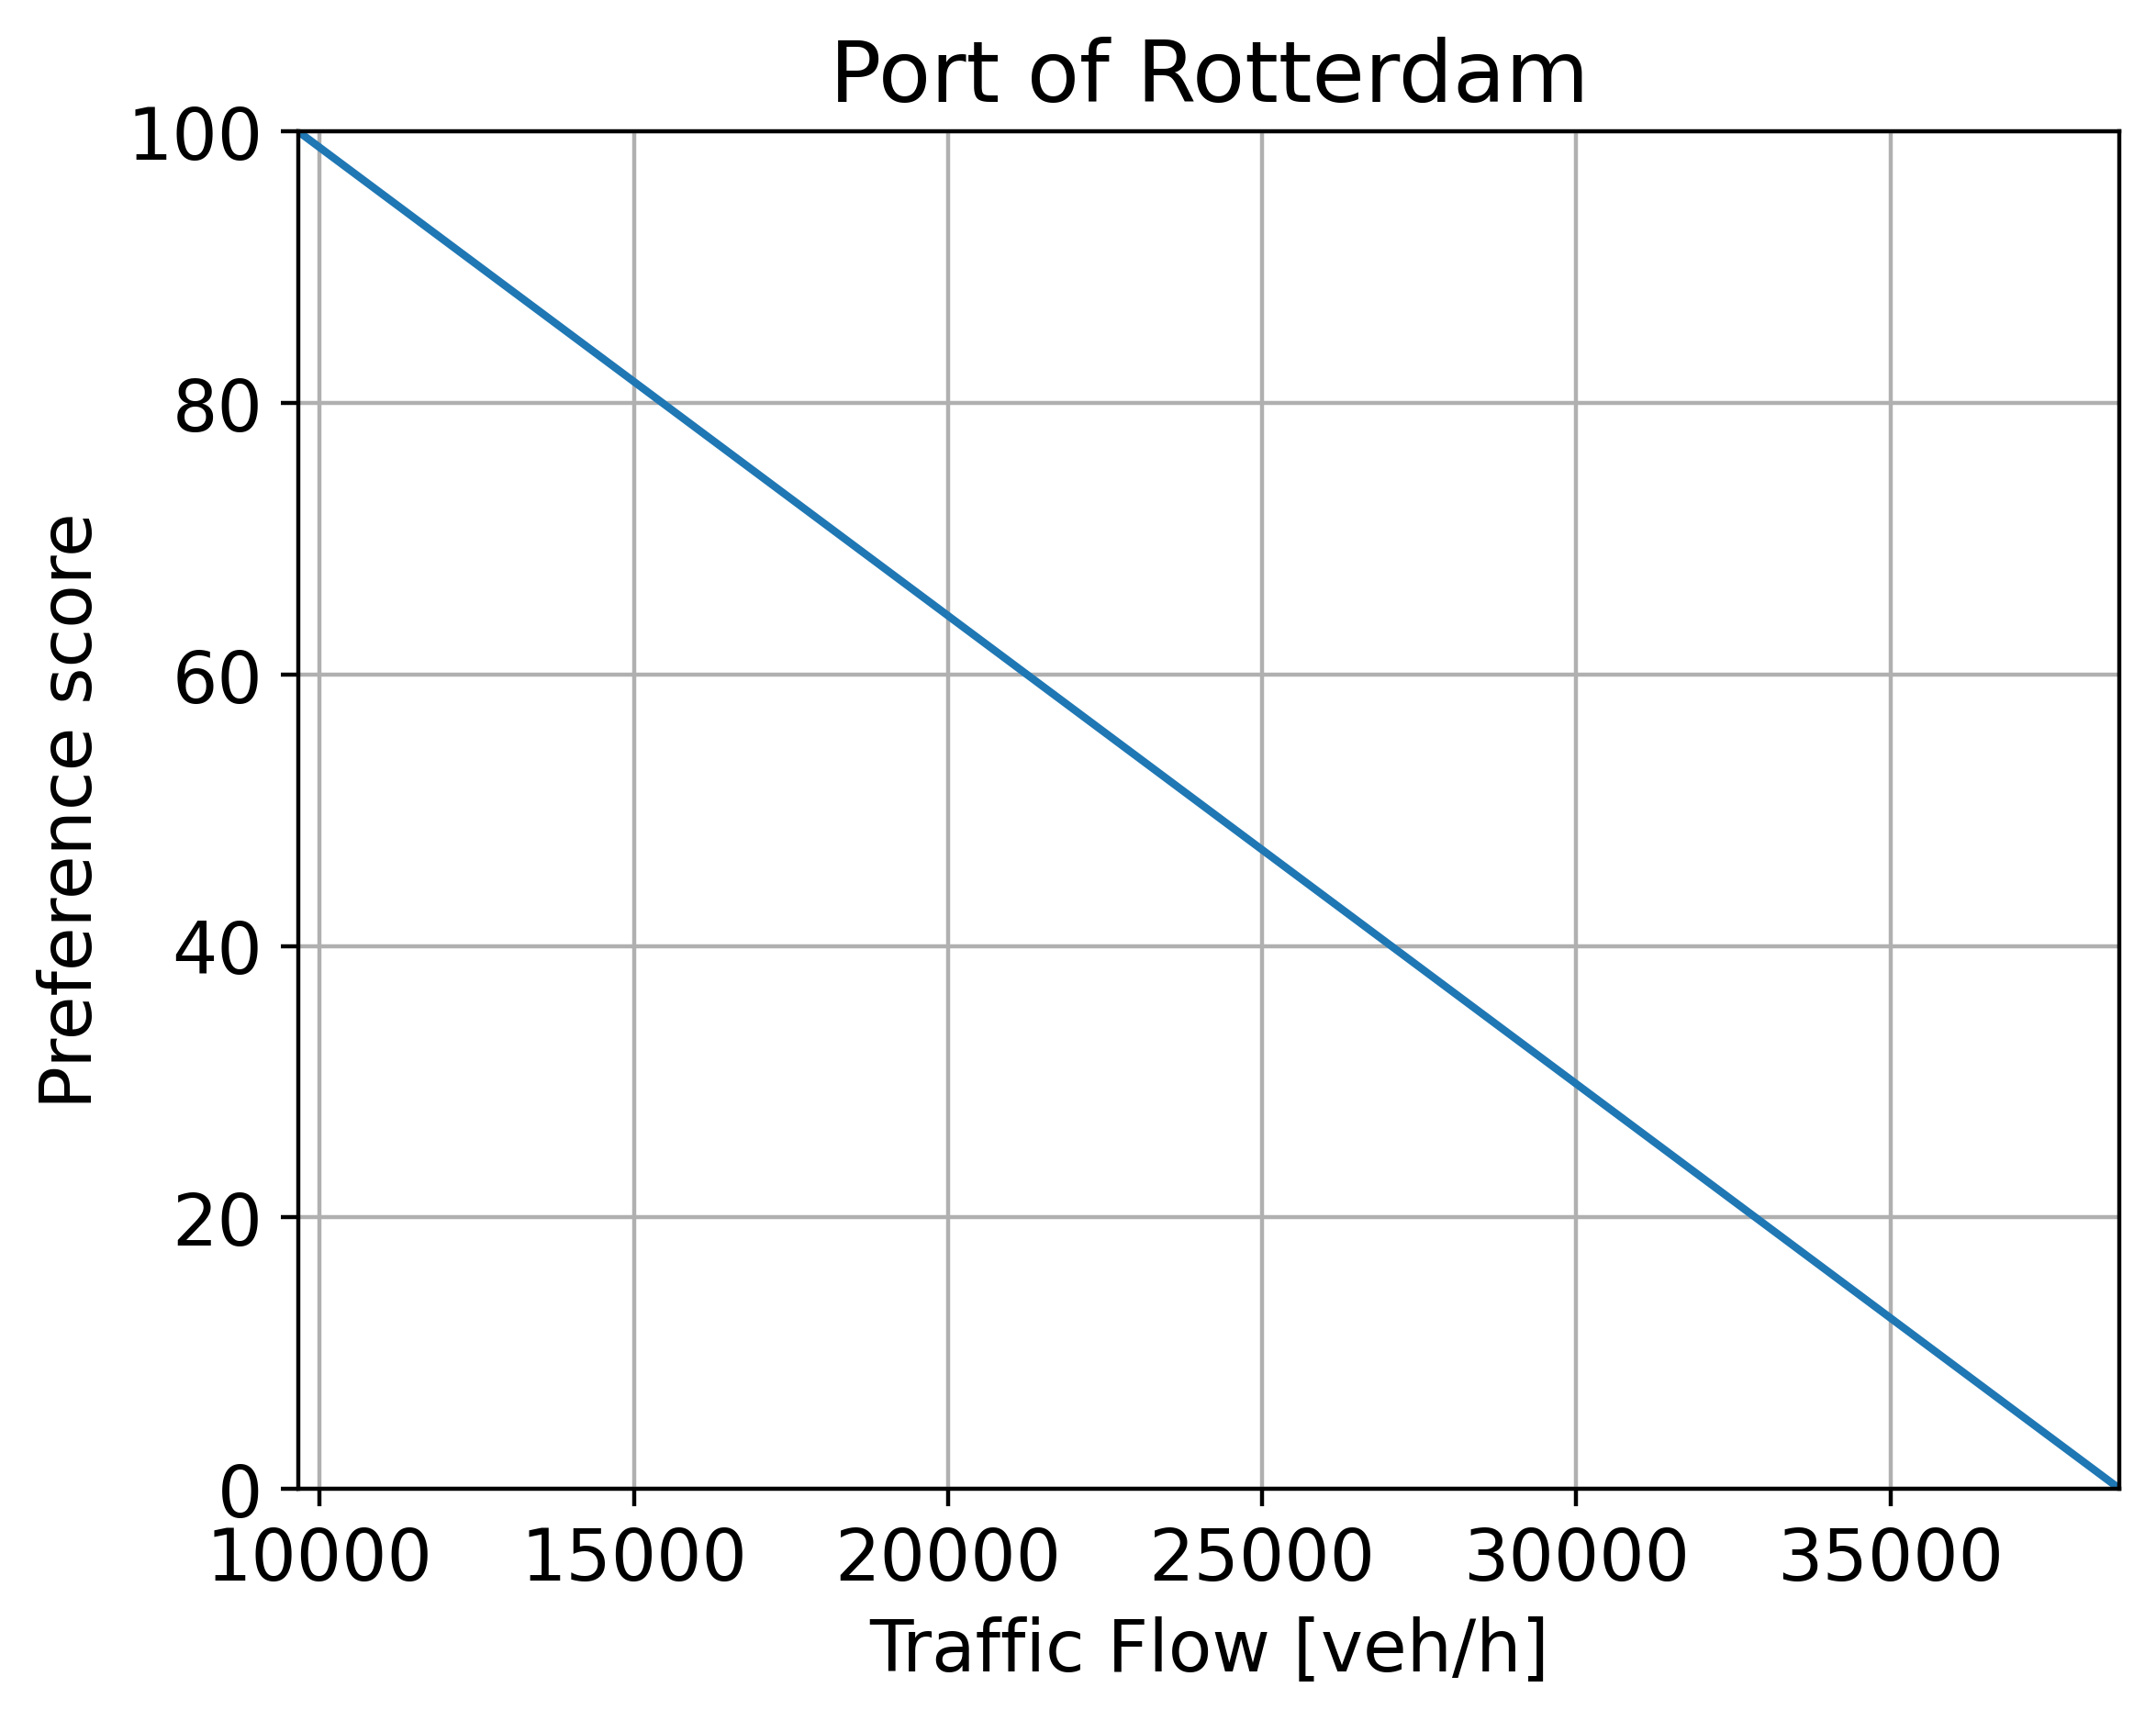

In [14]:
# plot the preference functions
constants_1 = np.linspace(min1, max1)
constants_2 = np.linspace(min2, max2)

pref_1 = 100 * max1 / (max1 - min1) + 100 * constants_1 / (min1 - max1)
pref_2 = 100 * max2 / (max2 - min2) + 100 * constants_2 / (min2 - max2)

# print('1:')
# print('a = ', 100/ (min1 - max1))
# print('b = ', 100 * max1 / (max1 - min1))
# print()
# print('2:')	
# print('a = ', 100/ (min2 - max2))
# print('b = ', 100 * max2 / (max2 - min2))


fig = plt.figure()
ax1 = fig.add_subplot(1, 1, 1)
ax1.plot(constants_1, pref_1)
ax1.set_xlim((min1, max1))
ax1.set_ylim((0, 100))
ax1.set_title('Rijkswaterstaat')
ax1.set_xlabel('Costs [€]')
ax1.set_ylabel('Preference score')
ax1.grid()
plt.savefig('preferences1.png')
fig = plt.figure()
ax2 = fig.add_subplot(1, 1, 1)
ax2.plot(constants_2, pref_2)
ax2.set_xlim((min2, max2))
ax2.set_ylim((0, 100))
ax2.set_title('Port of Rotterdam')
ax2.set_xlabel('Traffic Flow [veh/h]')
ax2.set_ylabel('Preference score')
ax2.grid()
plt.savefig('preferences2.png')

In [11]:
from genetic_algorithm_pfm import GeneticAlgorithm


weights = [0.2, 0.8]

def objective(variables):
    p1 = preference_P1(variables)
    p2 = preference_P2(variables)

    return weights, [p1, p2]

options = {
    'aggregation': 'tetra',
    "n_pop": 120,
    "max_stall": 20,
    "n_iter": 1000,
    "n_bits": 8,
    "r_cross": 0.9
}

# run the GA and print its result
ga = GeneticAlgorithm(objective=objective, constraints=[], bounds=bounds, options=options)
score, design_variables, _ = ga.run()

print()
print('Results multi-objective optimisation')
print(f'x1 = {design_variables[0]} and x2 = {design_variables[1]}.')

The type of aggregation is set to tetra
Generation   Best score   Mean             Max stall    Diversity    Number of non-feasible results
No initial starting point for the optimization with tetra is given. A random population is generated.
0            -100.0       -42.2353         1            0.012        0           
1            -100.0       -78.0615         2            0.225        0           
2            -100.0       -89.0381         3            0.208        0           
3            -100.0       -88.3212         4            0.404        0           
4            -100.0       -90.8642         5            0.4          0           
5            -100.0       -89.6557         6            0.404        0           
6            -100.0       -96.4771         7            0.421        0           
7            -100.0       -94.3068         8            0.438        0           
8            -100.0       -92.8601         9            0.433        0           
9            -100.0 

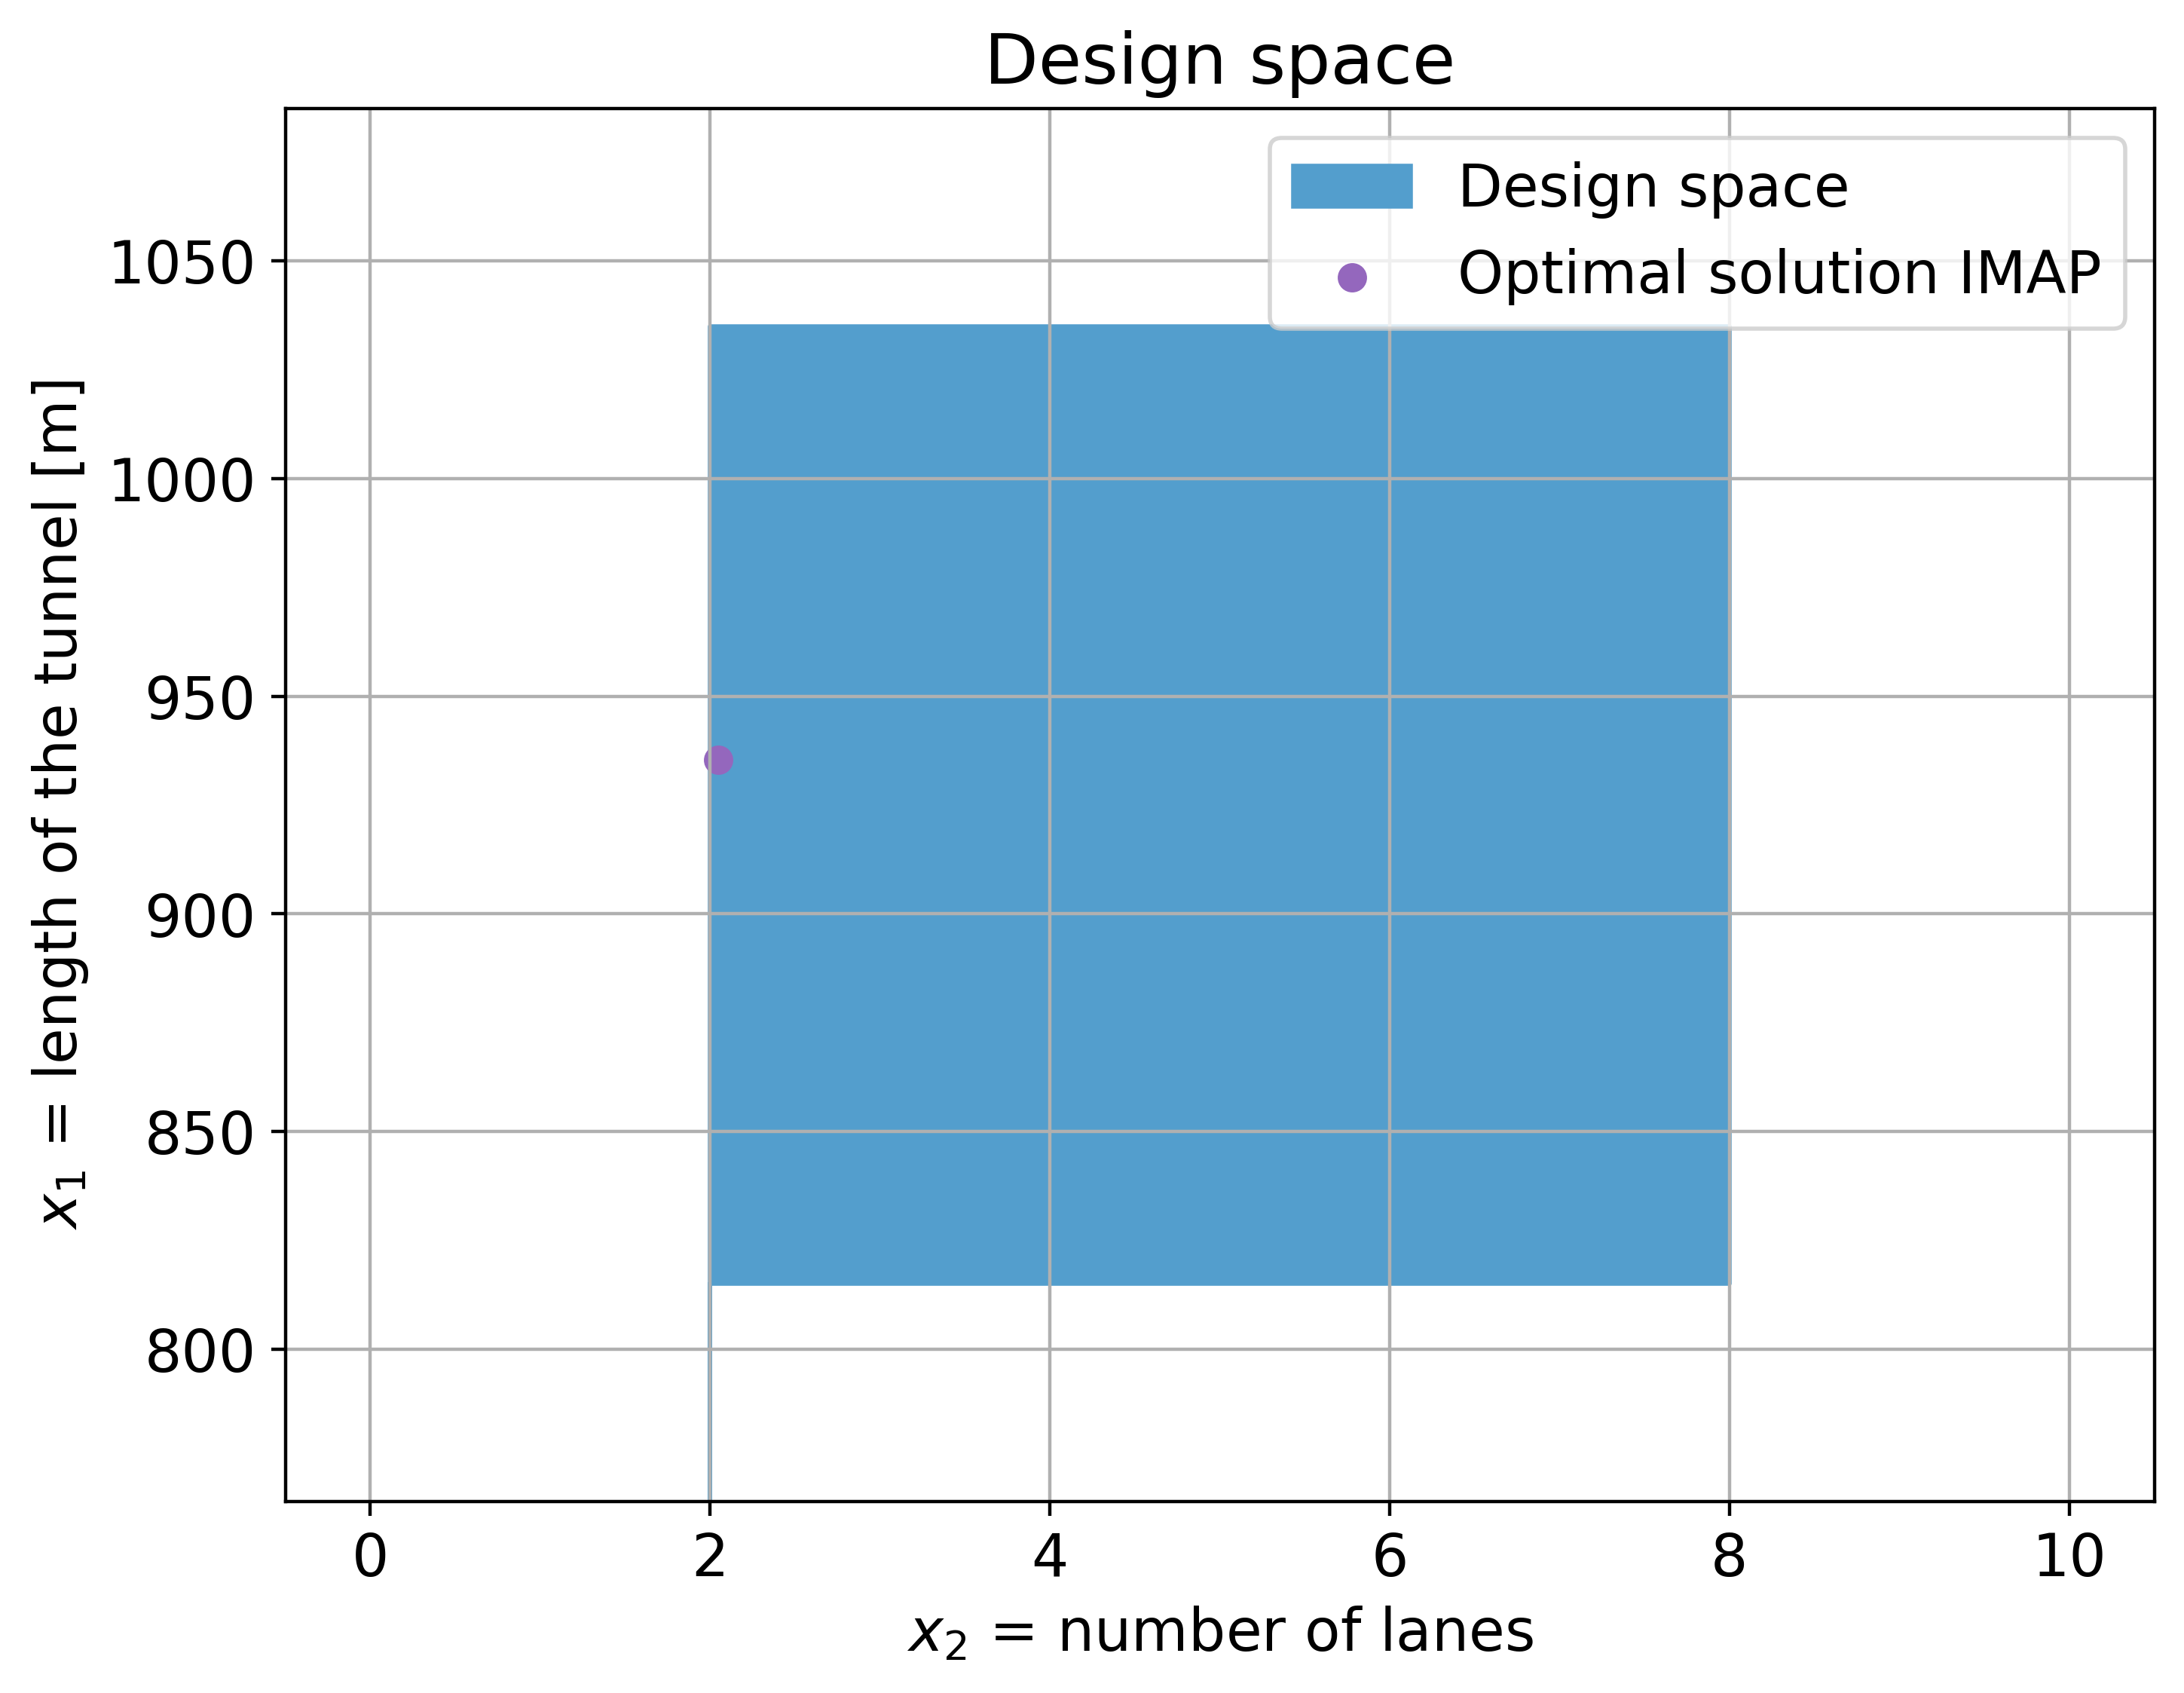

In [15]:
# create figure that shows the results in the design space
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_ylim((b1-50, b2+50))
ax.set_xlim((b3-2.5, b4+2.5))
ax.set_xlabel(r'$x_2$ = number of lanes')
ax.set_ylabel(r'$x_1$ = length of the tunnel [m]')
ax.set_title('Design space')

# define corner points of design space
x_fill = [b3, b4, b4, b3]
y_fill = [b1, b1, b2, b2]

ax.fill_between(x_fill, y_fill, color='#539ecd', label='Design space')
ax.scatter(design_variables[1], design_variables[0], label='Optimal solution IMAP', color='tab:purple')

ax.grid()  # show grid
ax.legend()
plt.savefig('design_space.png');  # show legend

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=88990155-7c6b-42b7-9b34-d0621db6d6b1' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>